# Mental Health & Depression Analysis: EDA & Baseline Random Forest

## 🧠 Psychological & Machine Learning

Depression is a multi-faceted mental health disorder influenced by demographic factors, cognitive stressors (work/academic pressure), clinical history (family background, suicidal thoughts), and biological/lifestyle regulators (sleep and nutrition).

This notebook contains a **Exploratory Data Analysis (EDA)** on the Kaggle Mental Health dataset. Check clinical, psychological, and lifestyle variables relate to the target (`Depression`), clean noisy data, and build a baseline **Random Forest Classifier** to model and predict depression risk.

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [60]:
# Loading dataset
df = pd.read_csv('train.csv')
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.info()

Dataset Shape: 140700 rows, 20 columns

<class 'pandas.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  str    
 2   Gender                                 140700 non-null  str    
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  str    
 5   Working Professional or Student        140700 non-null  str    
 6   Profession                             104070 non-null  str    
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction         

In [61]:
# Print missing values summary
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': df.isnull().sum(), 'Percentage (%)': missing_pct})
missing_df[missing_df['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)

,Missing Values,Percentage (%)
Academic Pressure,112803,80.172708
Study Satisfaction,112803,80.172708
CGPA,112802,80.171997
Profession,36630,26.034115
Work Pressure,27918,19.842217
Job Satisfaction,27910,19.836532
Dietary Habits,4,0.002843
Financial Stress,4,0.002843
Degree,2,0.001421


In [62]:
df.columns

Index(['id', 'Name', 'Gender', 'Age', 'City',
       'Working Professional or Student', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='str')

In [63]:
df['Working Professional or Student']

0         Working Professional
1         Working Professional
2                      Student
3         Working Professional
4         Working Professional
                  ...         
140695    Working Professional
140696    Working Professional
140697    Working Professional
140698    Working Professional
140699                 Student
Name: Working Professional or Student, Length: 140700, dtype: str

In [64]:
df['Working Professional or Student'].value_counts()

Working Professional or Student
Working Professional    112799
Student                  27901
Name: count, dtype: int64

In [65]:
len(df)

140700

## 2. Target Variable Analysis: Depression Prevalence

We will analyze the prevalence of depression in the dataset. Since this is our classification target, understanding the class balance is key.

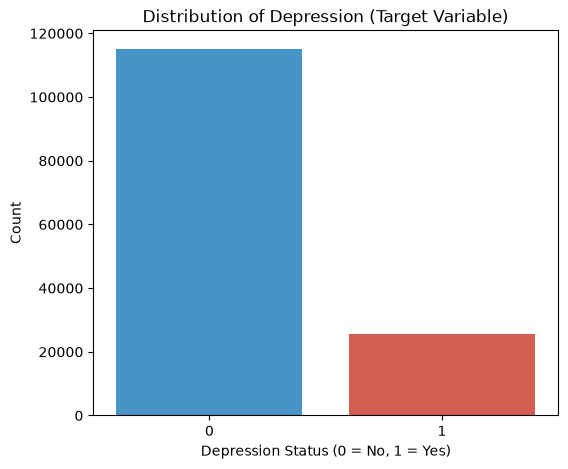

In [66]:
# Visualizing the target variable distribution
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x='Depression', hue='Depression', palette=['#3498db', '#e74c3c'], legend=False)
plt.title('Distribution of Depression (Target Variable)')
plt.xlabel('Depression Status (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

## 3. Demographic Analysis (Gender, Age, and Occupation)

Let's look at how demographic parameters like Gender, Age, and whether the respondent is a Student or Working Professional correlate with depression rates.

Text(0.5, 1.0, 'Age Distribution by Depression Status')

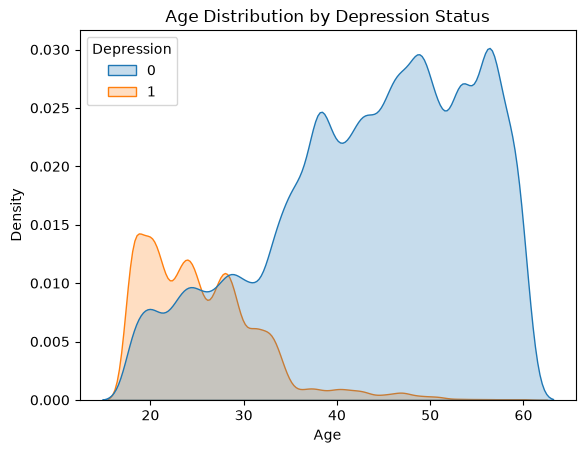

In [67]:
# Age Distribution by Depression
sns.kdeplot(data=df, x='Age', hue='Depression', fill=True)
plt.title('Age Distribution by Depression Status')

<Axes: xlabel='Gender', ylabel='Depression'>

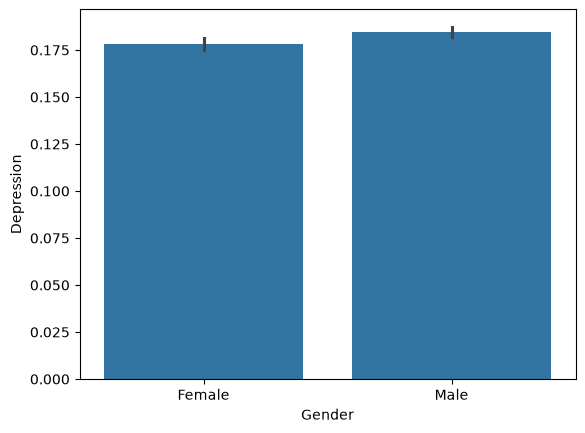

In [68]:
# Gender vs Depression
sns.barplot(data=df, x='Gender', y='Depression')

## 4. Psychological Stress Factors: Pressure & Satisfaction

Stress triggers are markers of depression. We have academic/work pressure and study/job satisfaction. 
These variables are split between students and working professionals.

/var/folders/jq/4mq4l9p14q36vpn5kmyfcdw00000gn/T/ipykernel_92405/2750056971.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.dropna(subset=['Job Satisfaction']), x='Job Satisfaction', y='Depression', ax=axes[1, 0], palette='Blues', errorbar=None)
/var/folders/jq/4mq4l9p14q36vpn5kmyfcdw00000gn/T/ipykernel_92405/2750056971.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.dropna(subset=['Study Satisfaction']), x='Study Satisfaction', y='Depression', ax=axes[1, 1], palette='Purples', errorbar=None)


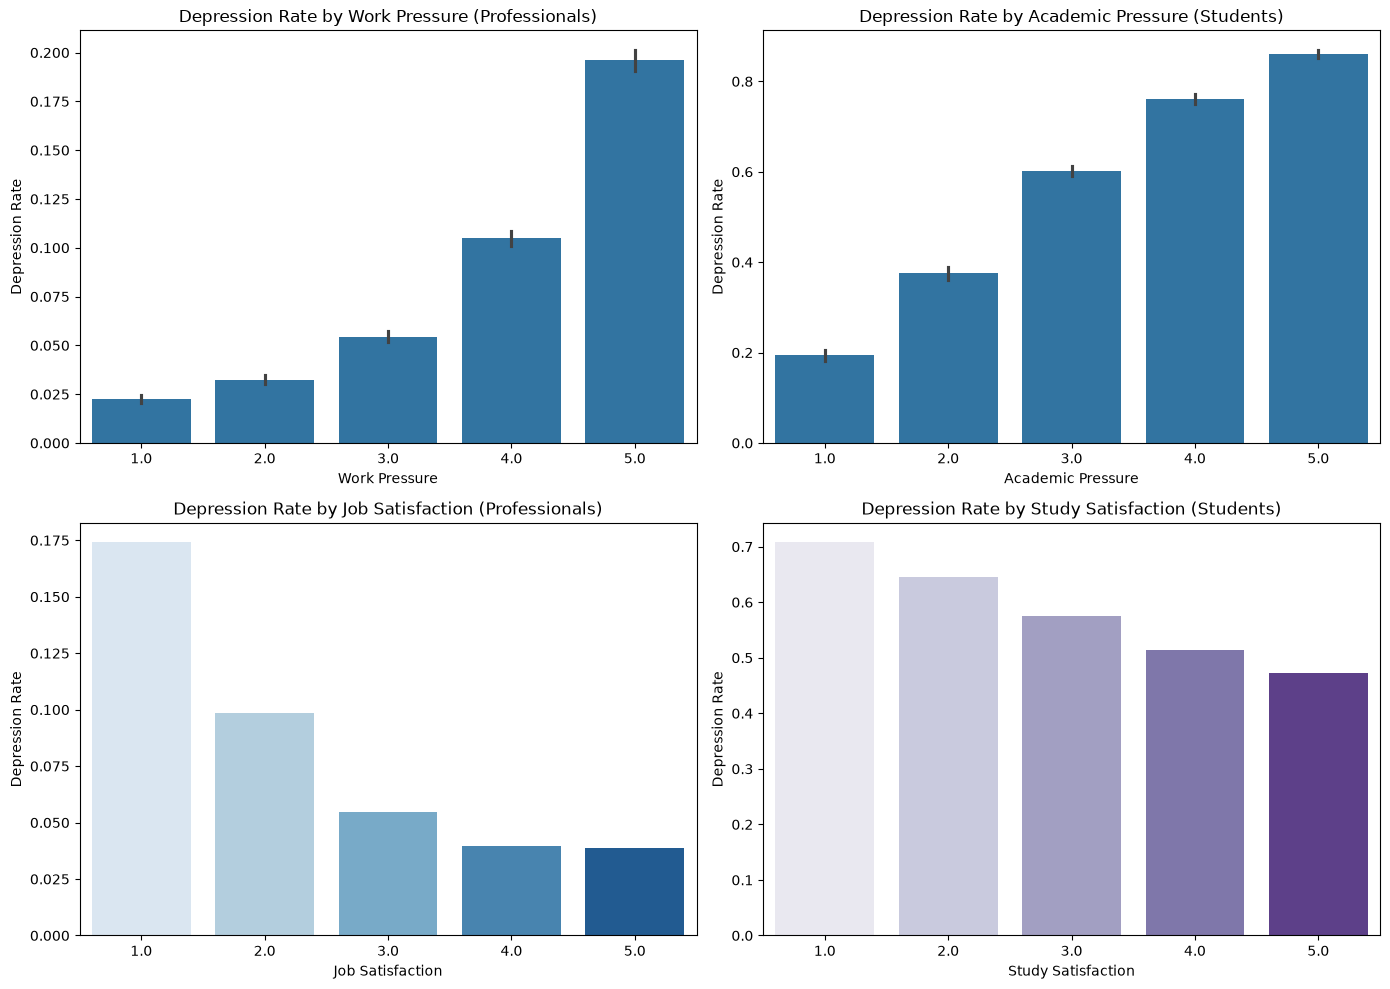

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Work Pressure (Professionals) vs Depression
sns.barplot(data=df.dropna(subset=['Work Pressure']), x='Work Pressure', y='Depression', ax=axes[0, 0])
axes[0, 0].set_title('Depression Rate by Work Pressure (Professionals)')
axes[0, 0].set_ylabel('Depression Rate')

# 2. Academic Pressure (Students) vs Depression
sns.barplot(data=df.dropna(subset=['Academic Pressure']), x='Academic Pressure', y='Depression', ax=axes[0, 1])
axes[0, 1].set_title('Depression Rate by Academic Pressure (Students)')
axes[0, 1].set_ylabel('Depression Rate')

# 3. Job Satisfaction vs Depression
sns.barplot(data=df.dropna(subset=['Job Satisfaction']), x='Job Satisfaction', y='Depression', ax=axes[1, 0], palette='Blues', errorbar=None)
axes[1, 0].set_title('Depression Rate by Job Satisfaction (Professionals)')
axes[1, 0].set_ylabel('Depression Rate')

# 4. Study Satisfaction vs Depression
sns.barplot(data=df.dropna(subset=['Study Satisfaction']), x='Study Satisfaction', y='Depression', ax=axes[1, 1], palette='Purples', errorbar=None)
axes[1, 1].set_title('Depression Rate by Study Satisfaction (Students)')
axes[1, 1].set_ylabel('Depression Rate')

plt.tight_layout()
plt.show()

## 5. Lifestyle & Biological Regulators (Sleep & Nutrition)

Psychological and physiological perspective:
- **Sleep deprivation** disrupts the circadian rhythm, alters neuroendocrine pathways, and is a strong predictor of depression.
- **Dietary Habits** represent nutrition, affecting the gut-brain axis and overall neurochemical balance.

/var/folders/jq/4mq4l9p14q36vpn5kmyfcdw00000gn/T/ipykernel_92405/2556163100.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sleep, x='Sleep Duration', y='Depression', order=sleep_order, palette='crest', ax=axes[0], errorbar=None)


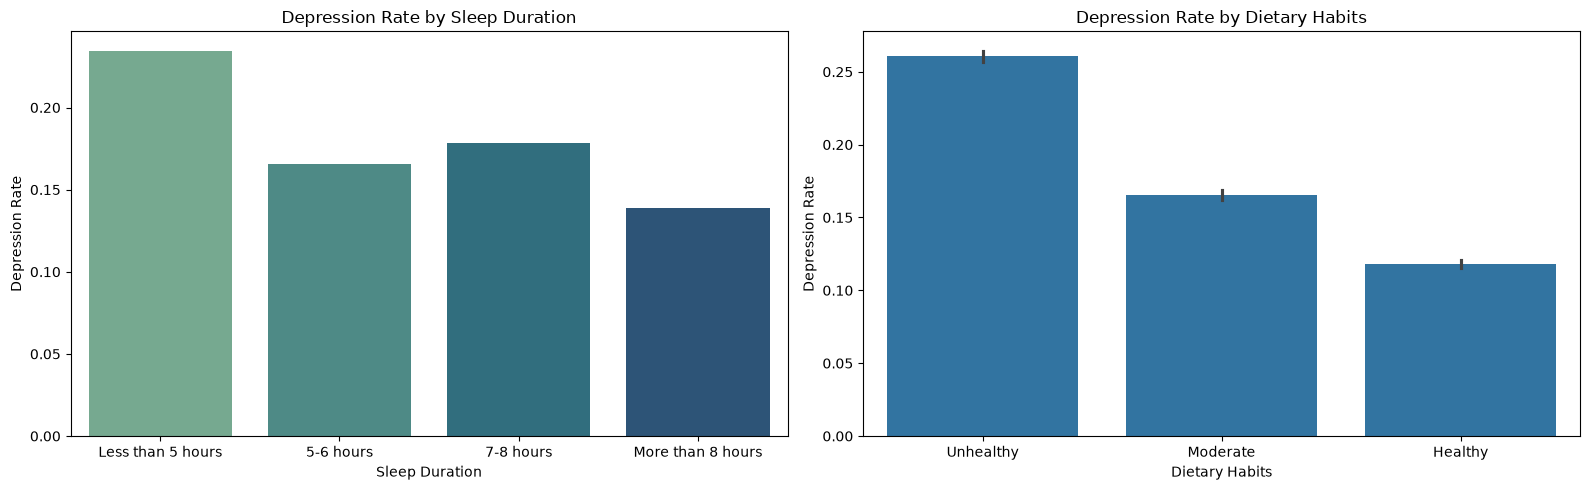

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sleep Duration vs Depression
# Filter to the top categories to avoid visualization noise
sleep_order = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours']
df_sleep = df[df['Sleep Duration'].isin(sleep_order)]
sns.barplot(data=df_sleep, x='Sleep Duration', y='Depression', order=sleep_order, palette='crest', ax=axes[0], errorbar=None)
axes[0].set_title('Depression Rate by Sleep Duration')
axes[0].set_ylabel('Depression Rate')

# Dietary Habits vs Depression
diet_order = ['Unhealthy', 'Moderate', 'Healthy']
df_diet = df[df['Dietary Habits'].isin(diet_order)]
sns.barplot(data=df_diet, x='Dietary Habits', y='Depression', order=diet_order, ax=axes[1])
axes[1].set_title('Depression Rate by Dietary Habits')
axes[1].set_ylabel('Depression Rate')

plt.tight_layout()
plt.show()

## 6. Clinical Indicators: Suicidal Thoughts & Family History

Psychology strongly links family genetics and previous suicidal ideation to depressive episodes.

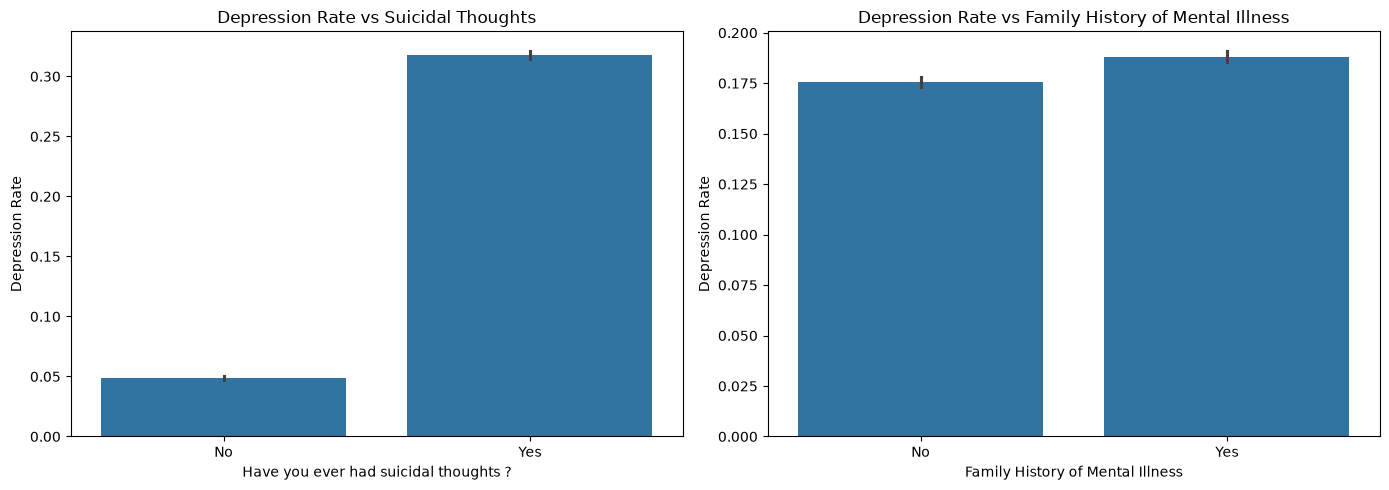

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Suicidal Thoughts vs Depression
sns.barplot(data=df, x='Have you ever had suicidal thoughts ?', y='Depression', ax=axes[0])
axes[0].set_title('Depression Rate vs Suicidal Thoughts')
axes[0].set_ylabel('Depression Rate')

# Family History vs Depression
sns.barplot(data=df, x='Family History of Mental Illness', y='Depression', ax=axes[1])
axes[1].set_title('Depression Rate vs Family History of Mental Illness')
axes[1].set_ylabel('Depression Rate')

plt.tight_layout()
plt.show()

## 7. Data Preprocessing & Encoding



### Preprocessing Strategy:
1. **Categorical Standardizing**
2. **Binary Encoding**: Map `Yes`/`No` features to `1`/`0`.
3. **Missing Value Imputation**:
4. **Categorical Encoding**:
   - One-hot encode features (`Gender`, `City`, `Working Professional or Student`, `Profession`, `Sleep Duration`, `Dietary Habits`, `Degree`).

In [72]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
def clean_and_preprocess(data_path):
    # Load raw data
    data = pd.read_csv(data_path)
    
    # 1. Clean 'Sleep Duration'
    sleep_mapping = {
        'Less than 5 hours': 'Less than 5 hours', '5-6 hours': '5-6 hours',
        '7-8 hours': '7-8 hours', 'More than 8 hours': 'More than 8 hours',
        '3-4 hours': 'Less than 5 hours', '2-3 hours': 'Less than 5 hours',
        '4-5 hours': 'Less than 5 hours', '1-2 hours': 'Less than 5 hours',
        '6-7 hours': '5-6 hours', '6-8 hours': '7-8 hours', '8-9 hours': 'More than 8 hours',
        '9-11 hours': 'More than 8 hours', '10-11 hours': 'More than 8 hours'
    }
    data['Sleep Duration'] = data['Sleep Duration'].map(sleep_mapping).fillna('7-8 hours')
    
    # 2. Clean 'Dietary Habits'
    diet_mapping = {
        'Moderate': 'Moderate', 'Unhealthy': 'Unhealthy', 'Healthy': 'Healthy',
        'More Healthy': 'Healthy', 'Less Healthy': 'Unhealthy', 'Less than Healthy': 'Unhealthy',
        'No Healthy': 'Unhealthy', 'Yes': 'Moderate', 'No': 'Moderate'
    }
    data['Dietary Habits'] = data['Dietary Habits'].map(diet_mapping).fillna('Moderate')
    
    # 3. Clean Binary Fields ('Yes'/'No' -> 1/0)
    binary_cols = ['Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']
    for col in binary_cols:
        data[col] = data[col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)
        
    # 4. Handle work vs study pressure missing values
    student_cols = ['Academic Pressure', 'CGPA', 'Study Satisfaction']
    professional_cols = ['Work Pressure', 'Job Satisfaction']
    
    for col in student_cols:
        data[col] = data[col].fillna(0)
    for col in professional_cols:
        data[col] = data[col].fillna(0)
        
    # Fill other small missing numerical features (e.g. Financial Stress)
    data['Financial Stress'] = data['Financial Stress'].fillna(data['Financial Stress'].mode()[0])
    
    # Fill small missing categorical features
    data['Profession'] = data['Profession'].fillna('Student')
    data['Degree'] = data['Degree'].fillna('Unknown')
    
    # Drop Name and id since they don't carry predictive signals
    data = data.drop(columns=['id', 'Name'], errors='ignore')
    
    # 5. One-Hot Encoding for categorical features
    categorical_cols = ['Gender', 'City', 'Working Professional or Student', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree']
    data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
    
    return data

clean_df = clean_and_preprocess('train.csv')
print(f"Preprocessed Data Shape: {clean_df.shape[0]} rows, {clean_df.shape[1]} columns")
clean_df.head()

Preprocessed Data Shape: 140700 rows, 293 columns


,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,...,Degree_S.Arch,Degree_S.Pharm,Degree_S.Tech,Degree_UX/UI Designer,Degree_Unite,Degree_Unknown,Degree_Veda,Degree_Vivaan,Degree_Vrinda,Degree_Working Professional
0,49.0,0.0,5.0,0.00,0.0,2.0,0,1.0,2.0,0,...,False,False,False,False,False,False,False,False,False,False
1,26.0,0.0,4.0,0.00,0.0,3.0,1,7.0,3.0,0,...,False,False,False,False,False,False,False,False,False,False
2,33.0,5.0,0.0,8.97,2.0,0.0,1,3.0,1.0,0,...,False,False,False,False,False,False,False,False,False,False
3,22.0,0.0,5.0,0.00,0.0,1.0,1,10.0,1.0,1,...,False,False,False,False,False,False,False,False,False,False
4,30.0,0.0,1.0,0.00,0.0,1.0,1,9.0,4.0,1,...,False,False,False,False,False,False,False,False,False,False


In [73]:
clean_df.columns.value_counts()

Age                            1
Academic Pressure              1
Work Pressure                  1
CGPA                           1
Study Satisfaction             1
                              ..
Degree_Unknown                 1
Degree_Veda                    1
Degree_Vivaan                  1
Degree_Vrinda                  1
Degree_Working Professional    1
Name: count, Length: 293, dtype: int64

In [74]:
df.shape

(140700, 20)

In [75]:
clean_df.shape

(140700, 293)

## 8. Baseline Random Forest Classifier

Split the preprocessed data, fit a baseline Random Forest Classifier, evaluate performance, and plot feature importances check factors contribute the most to depression prediction.

In [76]:
from sklearn.model_selection import train_test_split
# Split features and target
X = clean_df.drop(columns=['Depression'])
y = clean_df['Depression']

# Split into Train and Validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

Training set shape: (112560, 292)
Validation set shape: (28140, 292)


In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, RocCurveDisplay

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_val)
y_prob = rf_model.predict_proba(X_val)[:, 1]

# Evaluation
print(f"Accuracy Score: {accuracy_score(y_val, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_val, y_prob):.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_pred))

Accuracy Score: 0.9240
ROC AUC Score: 0.9645

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95     23027
           1       0.84      0.71      0.77      5113

    accuracy                           0.92     28140
   macro avg       0.89      0.84      0.86     28140
weighted avg       0.92      0.92      0.92     28140



TypeError: RocCurveDisplay.from_estimator() got an unexpected keyword argument 'color'

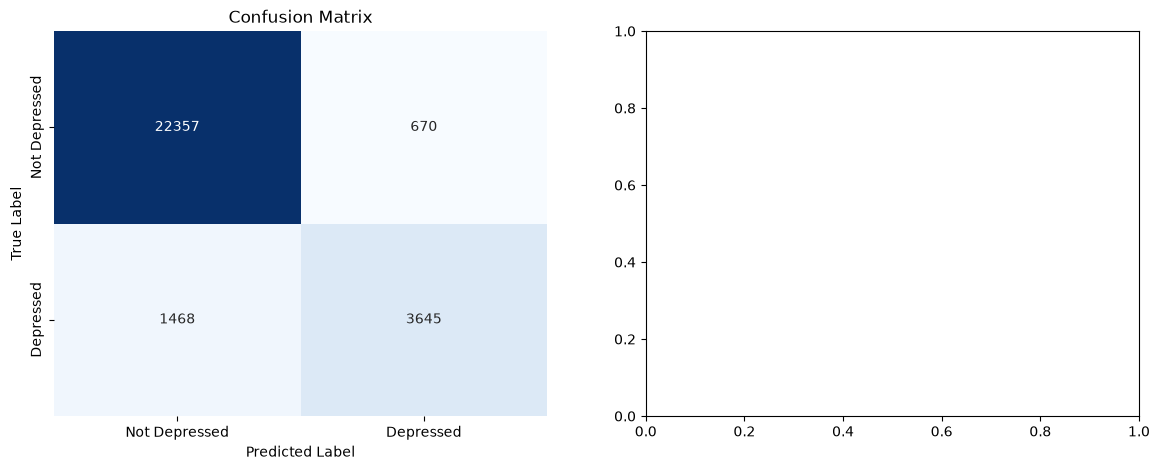

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Not Depressed', 'Depressed'], yticklabels=['Not Depressed', 'Depressed'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot ROC Curve
RocCurveDisplay.from_estimator(rf_model, X_val, y_val, ax=axes[1], color='#e74c3c')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Top 15 Feature Importances
importances = rf_model.feature_importances_
feature_names = X.columns
rf_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importances.head(15), y=rf_importances.head(15).index, palette='viridis')
plt.title('Top 15 Most Influential Features (Random Forest Feature Importance)')
plt.xlabel('Importance Value')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## 9. Interactive Inference Pipeline & Streamlit Dashboard

To perform real-time, interactive predictions on new custom entries, we use a Streamlit web application dashboard.

Execute
```bash
uv run streamlit run app.py
```